In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

%env XLA_PYTHON_CLIENT_PREALLOCATE=False

PKLs = []
PKL_titles = []
DIR = "./output_dim5_mean0/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [19]:
[1]

'build_build_gaussian_rw_proposal_merge.pkl'

In [3]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'AR',
'build_build_gaussian_rw_proposal' : 'RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"Uncoupled AR/RW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

In [7]:
PKLs[3]

IndexError: list index out of range

In [62]:
t = jnp.argwhere(PKLs[i]['res'][6]==1)
t = t.reshape((1, t.shape[0], t.shape[1]))

In [6]:
i=0
max_size = PKLs[i]['res'][6].shape[1]
num_para = PKLs[i]['res'][6].shape[0]
max_temp_idx = max([jnp.max(jnp.argwhere(PKLs[i]['res'][6]==1), axis=0)[1] for i in range(n)])
max_temp_idx_per_proposal = {
    proposal:  jnp.max(jnp.argwhere(PKLs[idx_proposal[proposal][0]]['res'][6]==1), axis=0)[1] for proposal in idx_proposal}
log_normalization_constants = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx_per_proposal[proposal]] for idx in idx_proposal[proposal]] for proposal in idx_proposal}
def facteur(idx):
    M = PKLs[idx]['config']['num_parallel_chain']
    P = PKLs[idx]['config']['num_mcmc_steps']
    T = np.argmax(PKLs[idx]['res'][6]==1, axis=1)
    return T/T
    return T

    
log_normalization_constants_facteur = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx]*facteur(idx).reshape((num_para,1) ) for idx in idx_proposal[proposal]] for proposal in idx_proposal}


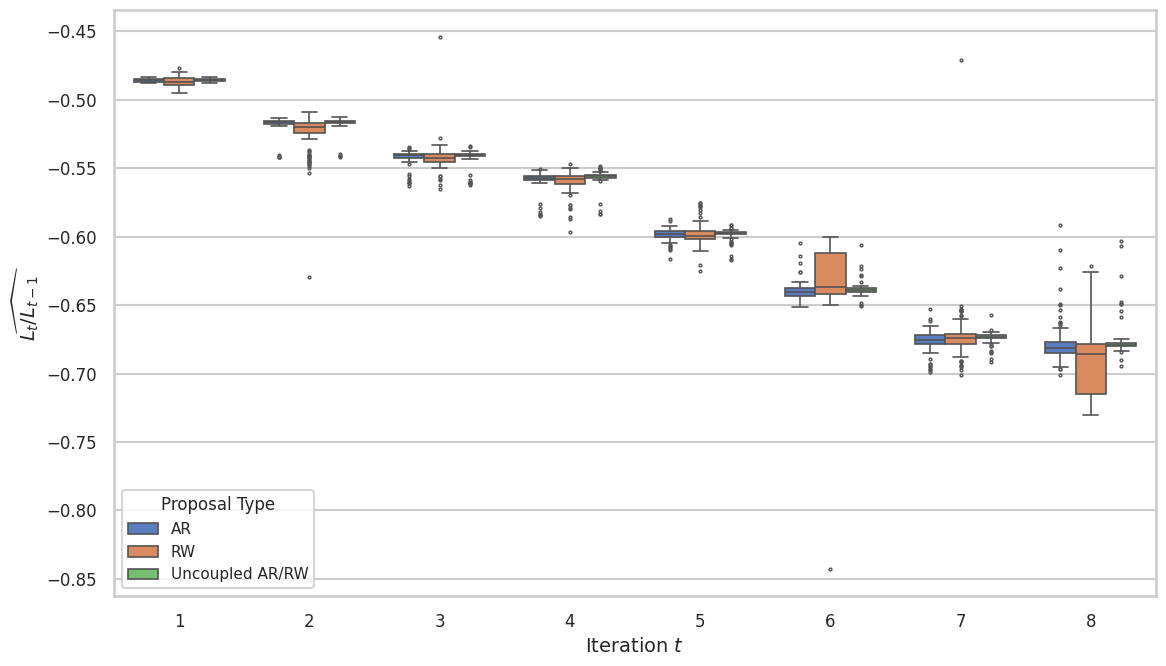

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style and context for better visuals
sns.set(style='whitegrid', context='talk', palette='muted')

# Construct all DataFrames
my_dfs = {
    proposal: [
        pd.DataFrame(log_normalization_constants_facteur[proposal][idx][:, :8], columns=list(range(1, 9)))
        .assign(Type=proposal)
        for idx in range(len(idx_proposal[proposal]))
    ]
    for proposal in idx_proposal
}

# Combine the DataFrames
combined_df = pd.concat(
    [pd.concat(my_dfs[proposal]) for proposal in idx_proposal],
    ignore_index=True
)

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Iteration', value_name='Value')

# Improve plot size and layout
plt.figure(figsize=(12, 7))

# Create the boxplot with better aesthetics
sns.boxplot(
    x='Iteration',
    y='Value',
    hue='Type',
    data=melted_df,
    showfliers=True,
    linewidth=1.2,
    fliersize=2,
    width=0.7
)

# Improve legend and labels
plt.xlabel(r'Iteration $t$', fontsize=14)
plt.ylabel(r'$ \widehat{L_t/L_{t-1}}$', fontsize=14)
#plt.title('Log Normalization Constants Over Iterations', fontsize=16, weight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Proposal Type', title_fontsize=12, fontsize=11)
plt.tight_layout()

# Save or show the plot
plt.savefig(DIR + "boxplot.pdf", dpi=300)
# plt.show()  # Uncomment to display in notebook/script


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style and context for better visuals
sns.set(style='whitegrid', context='talk', palette='muted')

# Construct all DataFrames
my_dfs = {
    proposal: [
        pd.DataFrame(log_normalization_constants_facteur[proposal][idx][:, :11], columns=list(range(1, 12)))
        .assign(Type=proposal)
        for idx in range(len(idx_proposal[proposal]))
    ]
    for proposal in idx_proposal
}

# Combine the DataFrames
combined_df = pd.concat(
    [pd.concat(my_dfs[proposal]) for proposal in idx_proposal],
    ignore_index=True
)

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Iteration', value_name='Value')

# Improve plot size and layout
plt.figure(figsize=(12, 7))

# Create the boxplot with better aesthetics
sns.boxplot(
    x='Iteration',
    y='Value',
    hue='Type',
    data=melted_df,
    showfliers=False,
    linewidth=1.2,
    fliersize=2,
    width=0.7
)

# Improve legend and labels
plt.xlabel(r'Iteration $t$', fontsize=14)
plt.ylabel(r'$\log$ normalization constant proxy: $T \times \widehat{L_t/L_{t-1}}$', fontsize=14)
#plt.title('Log Normalization Constants Over Iterations', fontsize=16, weight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Proposal Type', title_fontsize=12, fontsize=11)
plt.tight_layout()

# Save or show the plot
plt.savefig(DIR + "boxplot.pdf", dpi=300)
# plt.show()  # Uncomment to display in notebook/script


In [47]:
idx_proposal


{'build_build_autoregressive_gaussian_proposal': [0],
 'build_build_gaussian_rw_proposal': [1],
 'build_build_uncoupled_autoregressive_gaussian_proposal': [2]}

In [41]:
log_normalization_constants_facteur[proposal][0][:,11]

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#construct all dfs

my_dfs = {proposal: 
              [
                  pd.DataFrame(log_normalization_constants_facteur[proposal][idx], columns=list(range(1, max_temp_idx_per_proposal[proposal]))).assign(Type=proposal) 
                  for idx in range(len(idx_proposal[proposal]))]
           for proposal in idx_proposal
         }

#


# Combine the DataFrames
combined_df = pd.concat([pd.concat([df for df in my_dfs[proposal]]) for proposal in idx_proposal])

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')


# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', hue='Type', data=melted_df, showfliers=False)

# Add titles and labels
plt.title('Boxplot of log normalization constant at each iteration')
plt.xlabel('Iteration')
plt.ylabel(r'log norm. constant ($T\times \log N^{-1} \sum_n w_t^n$)')

# Show the plot
plt.savefig(DIR+"boxplot.png")

ValueError: Shape of passed values is (100, 13), indices imply (100, 9)

In [17]:
max_temp_idx_per_proposal

{'build_build_autoregressive_gaussian_proposal': Array(14, dtype=int32),
 'build_build_gaussian_rw_proposal': Array(14, dtype=int32),
 'build_build_uncoupled_autoregressive_gaussian_proposal': Array(14, dtype=int32)}